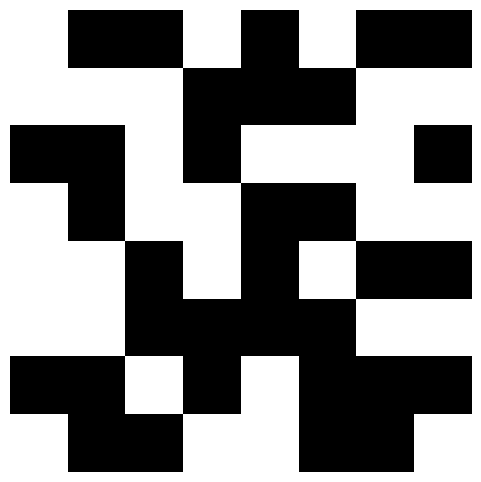

In [55]:

from all_pairs_similarity_analysis.all_pairs_matching import *
from all_pairs_similarity_analysis.visualization import draw_image
from os import path
import matplotlib.pyplot as plt
from PIL import Image

image = path.join(".","all_pairs_similarity_analysis", "images", "test_8x8.png")
chunk_size = 2
grayscale_bits_per_pixel = 1
shots = 2048
draw = True
iterations = None
circuit_output = "mpl"

img = Image.open(image).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()


In [56]:
# -----------------------------------------------------------------------
# Load and quantize the image.
# -----------------------------------------------------------------------
quantized = load_image_as_quantized_gray(
    image_path=image,
    bits_per_pixel=grayscale_bits_per_pixel,
)

# -----------------------------------------------------------------------
# Split the image into non-overlapping chunks and encode each as bits.
# -----------------------------------------------------------------------
chunks, positions, cropped_shape = split_into_nonoverlapping_chunks(
    quantized=quantized,
    chunk_size=chunk_size,
    bits_per_pixel=grayscale_bits_per_pixel,
)

num_chunks = len(chunks)
chunk_bits = len(chunks[0])

if not is_power_of_two(num_chunks):
    raise ValueError(
        f"This simple demo requires the number of chunks to be a power of two.\n"
        f"Got {num_chunks} chunks from cropped image shape {cropped_shape} "
        f"with chunk size {chunk_size}.\n"
        f"Try an image/chunk-size combination giving 2, 4, 8, 16, ... chunks."
    )


In [57]:

# -----------------------------------------------------------------------
# Classical duplicate count is used only for choosing Grover iterations
# and verifying results.
# -----------------------------------------------------------------------
duplicate_pairs = find_classical_duplicate_pairs(chunks)
num_good = len(duplicate_pairs)

if iterations is None:
    grover_iterations = choose_grover_iterations(num_chunks, num_good)
else:
    grover_iterations = iterations

# -----------------------------------------------------------------------
# Print problem summary.
# -----------------------------------------------------------------------
print("Problem summary")
print("---------------")
print(f"Input image:                {image}")
print(f"Cropped image shape used:   {cropped_shape}")
print(f"Chunk size:                 {chunk_size} x {chunk_size}")
print(f"Bits per pixel:             {1}")
print(f"Number of chunks m:         {num_chunks}")
print(f"Bits per chunk b:           {chunk_bits}")
print(f"Search space size m^2:      {num_chunks * num_chunks}")
print(f"Classical good ordered pairs, excluding i=j: {num_good}")
print(f"Grover iterations:          {grover_iterations}")

if num_good > 0:
    print("\nClassically known duplicate ordered pairs, for verification:")
    for pair in duplicate_pairs[:20]:
        i, j = pair
        print(f"  ({i}, {j}) at positions {positions[i]} and {positions[j]}")
    if len(duplicate_pairs) > 20:
        print(f"  ... and {len(duplicate_pairs) - 20} more")
else:
    print(
        "\nNo duplicate chunks were found classically. "
        "Grover has no marked state in this case, so measurement will be uninformative."
    )


Problem summary
---------------
Input image:                ./all_pairs_similarity_analysis/images/test_8x8.png
Cropped image shape used:   (8, 8)
Chunk size:                 2 x 2
Bits per pixel:             1
Number of chunks m:         16
Bits per chunk b:           4
Search space size m^2:      256
Classical good ordered pairs, excluding i=j: 16
Grover iterations:          3

Classically known duplicate ordered pairs, for verification:
  (0, 5) at positions (0, 0) and (2, 2)
  (0, 7) at positions (0, 0) and (2, 6)
  (5, 0) at positions (2, 2) and (0, 0)
  (5, 7) at positions (2, 2) and (2, 6)
  (7, 0) at positions (2, 6) and (0, 0)
  (7, 5) at positions (2, 6) and (2, 2)
  (2, 9) at positions (0, 4) and (4, 2)
  (2, 10) at positions (0, 4) and (4, 4)
  (9, 2) at positions (4, 2) and (0, 4)
  (9, 10) at positions (4, 2) and (4, 4)
  (10, 2) at positions (4, 4) and (0, 4)
  (10, 9) at positions (4, 4) and (4, 2)
  (3, 11) at positions (0, 6) and (4, 6)
  (11, 3) at positions (4, 6) a

In [58]:

# -----------------------------------------------------------------------
# Build the quantum circuit.
# -----------------------------------------------------------------------
circuit, idx_bits = build_duplicate_chunk_grover_circuit(
    chunks=chunks,
    grover_iterations=grover_iterations,
)


print("\nCircuit summary")
print("---------------")
print(f"Total qubits:               {circuit.num_qubits}")
print(f"Total classical bits:       {circuit.num_clbits}")
print(f"Circuit depth before transpile: {circuit.depth()}")

if draw:
    print("\nCircuit diagram")
    print("---------------")
    print(circuit.draw(output="text"))



Circuit summary
---------------
Total qubits:               20
Total classical bits:       8
Circuit depth before transpile: 743

Circuit diagram
---------------
           ┌───┐┌───┐     ┌───┐┌───┐          ┌───┐┌───┐          ┌───┐     »
      i_0: ┤ H ├┤ X ├──■──┤ X ├┤ X ├───────■──┤ X ├┤ X ├───────■──┤ X ├─────»
           ├───┤├───┤  │  ├───┤├───┤       │  ├───┤├───┤       │  ├───┤┌───┐»
      i_1: ┤ H ├┤ X ├──■──┤ X ├┤ X ├───────■──┤ X ├┤ X ├───────■──┤ X ├┤ X ├»
           ├───┤├───┤  │  ├───┤├───┤       │  ├───┤├───┤       │  ├───┤├───┤»
      i_2: ┤ H ├┤ X ├──■──┤ X ├┤ X ├───────■──┤ X ├┤ X ├───────■──┤ X ├┤ X ├»
           ├───┤├───┤  │  ├───┤├───┤       │  ├───┤├───┤       │  ├───┤├───┤»
      i_3: ┤ H ├┤ X ├──■──┤ X ├┤ X ├───────■──┤ X ├┤ X ├───────■──┤ X ├┤ X ├»
           ├───┤├───┤  │  └───┘├───┤┌───┐  │  └───┘├───┤┌───┐  │  └───┘├───┤»
      j_0: ┤ H ├┤ X ├──┼────■──┤ X ├┤ X ├──┼────■──┤ X ├┤ X ├──┼────■──┤ X ├»
           ├───┤├───┤  │    │  ├───┤├───┤  │    │  ├───┤├

In [59]:
# -----------------------------------------------------------------------
# Simulate the circuit.
# -----------------------------------------------------------------------
backend = AerSimulator()
transpiled = transpile(circuit, backend)

print(f"Circuit depth after transpile:  {transpiled.depth()}")

result = backend.run(transpiled, shots=shots).result()
counts = result.get_counts()

Circuit depth after transpile:  386



Top measured pairs:
-------------------
count=  142 | i=  0, j=  5 | pos_i=(0, 0), pos_j=(2, 2) | equal=True | i!=j=True | duplicate=True
count=  141 | i=  9, j= 10 | pos_i=(4, 2), pos_j=(4, 4) | equal=True | i!=j=True | duplicate=True
count=  139 | i=  9, j=  2 | pos_i=(4, 2), pos_j=(0, 4) | equal=True | i!=j=True | duplicate=True
count=  137 | i= 10, j=  2 | pos_i=(4, 4), pos_j=(0, 4) | equal=True | i!=j=True | duplicate=True
count=  132 | i=  5, j=  0 | pos_i=(2, 2), pos_j=(0, 0) | equal=True | i!=j=True | duplicate=True
count=  131 | i=  2, j= 10 | pos_i=(0, 4), pos_j=(4, 4) | equal=True | i!=j=True | duplicate=True
count=  129 | i= 11, j=  3 | pos_i=(4, 6), pos_j=(0, 6) | equal=True | i!=j=True | duplicate=True
count=  128 | i=  7, j=  5 | pos_i=(2, 6), pos_j=(2, 2) | equal=True | i!=j=True | duplicate=True
count=  124 | i=  7, j=  0 | pos_i=(2, 6), pos_j=(0, 0) | equal=True | i!=j=True | duplicate=True
count=  118 | i=  5, j=  7 | pos_i=(2, 2), pos_j=(2, 6) | equal=True | i!=j=T

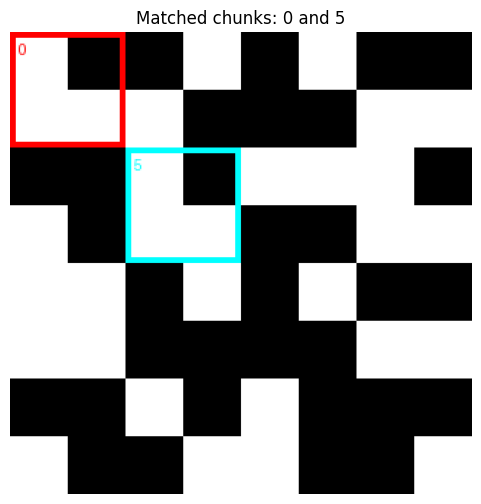

In [60]:
# -----------------------------------------------------------------------
# Display and verify the top measured pairs.
# -----------------------------------------------------------------------
print_top_results(
    counts=counts,
    idx_bits=idx_bits,
    chunks=chunks,
    positions=positions,
    max_rows=10,
)

top_bitstring = max(counts.items(), key=lambda kv: kv[1])[0]
top_pair = parse_measured_pair(top_bitstring, idx_bits)

highlight_matching_chunks(
    image_path=image,
    positions=positions,
    pair=top_pair,
    chunk_size=chunk_size,
    output_path="highlighted_match.png",
    show=True,
)